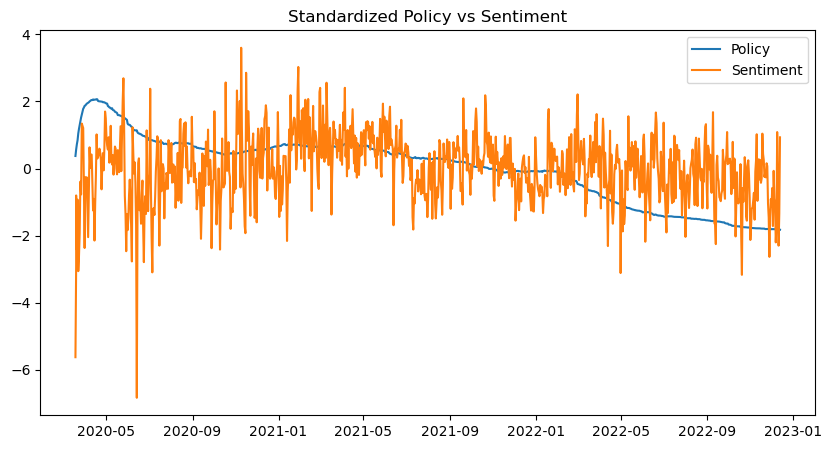

       tweet_volume  sentiment_mean  StringencyIndex_Average
count  9.970000e+02      997.000000               997.000000
mean   2.148549e+06        0.053327                45.743364
std    1.117659e+06        0.010572                16.533203
min    2.882770e+05       -0.018960                15.568649
25%    9.379070e+05        0.047163                31.449730
50%    2.234971e+06        0.053755                50.698432
75%    3.144302e+06        0.059915                56.723297
max    4.774322e+06        0.091392                79.927838


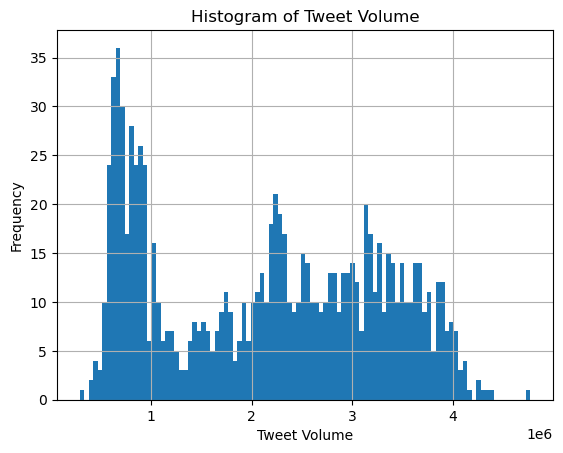

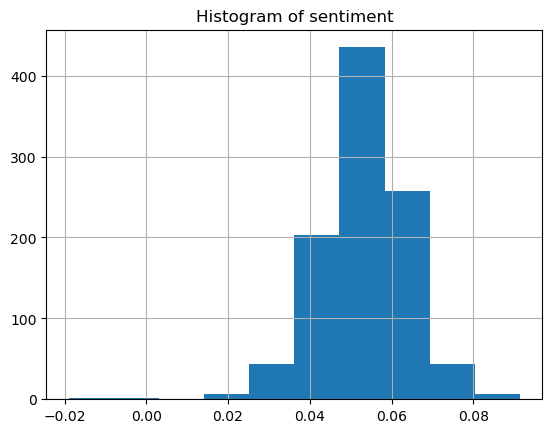

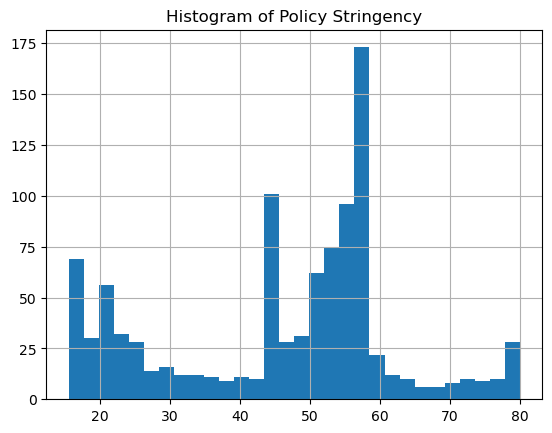

                         StringencyIndex_Average  sentiment_mean
StringencyIndex_Average                 1.000000        0.149212
sentiment_mean                          0.149212        1.000000
                         StringencyIndex_Average  tweet_volume
StringencyIndex_Average                 1.000000      0.707019
tweet_volume                            0.707019      1.000000


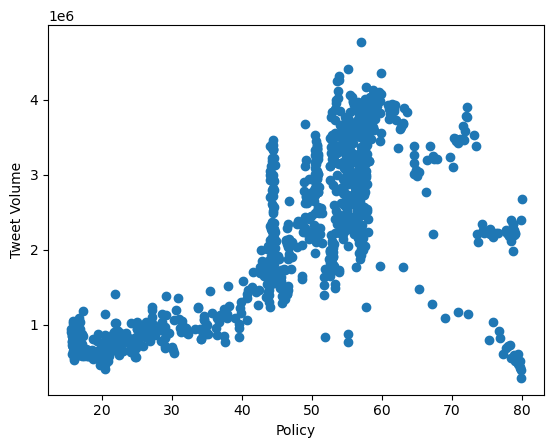

                            OLS Regression Results                            
Dep. Variable:           tweet_volume   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     994.5
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          6.99e-152
Time:                        12:14:41   Log-Likelihood:                -14954.
No. Observations:                 997   AIC:                         2.991e+04
Df Residuals:                     995   BIC:                         2.992e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                   -3

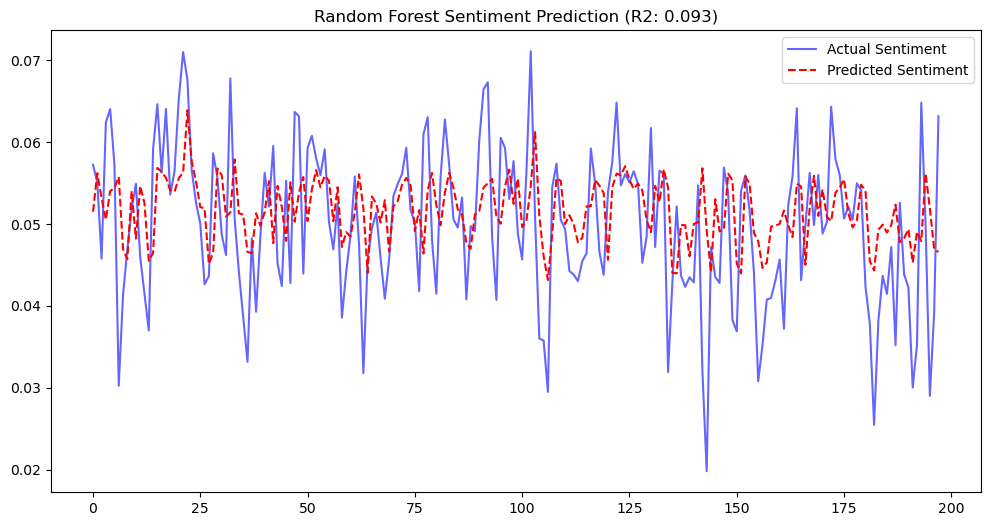


Feature Importances:
sentiment_lag1    0.489428
sentiment_lag3    0.162938
policy_lag7       0.123446
cases_lag1        0.117296
volume_lag1       0.106891
dtype: float64
                               SARIMAX Results                                
Dep. Variable:           tweet_volume   No. Observations:                  990
Model:               SARIMAX(1, 0, 0)   Log Likelihood              -13965.333
Date:                Mon, 13 Apr 2026   AIC                          27938.666
Time:                        12:14:41   BIC                          27958.256
Sample:                             0   HQIC                         27946.115
                                - 990                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
policy_lag7  4.901e+04   2300.183   

C:\Users\20458\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\20458\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

df1 = pd.read_csv("OxCGRT_compact_national_v1.csv")
df2 = pd.read_csv("daily_sentiment_volatility.csv")

df1['Date'] = pd.to_datetime(df1['Date'], format='%Y%m%d')
df2['date'] = pd.to_datetime(df2['date'])
policy = df1.groupby('Date').mean(numeric_only=True).reset_index()
merged = pd.merge(policy, df2, left_on='Date', right_on='date', how='inner')

# Standardized Policy vs Sentiment Plot
merged['policy_std'] = (merged['StringencyIndex_Average'] - merged['StringencyIndex_Average'].mean()) / merged['StringencyIndex_Average'].std()
merged['sentiment_std'] = (merged['sentiment_mean'] - merged['sentiment_mean'].mean()) / merged['sentiment_mean'].std()
plt.figure(figsize=(10,5))
plt.plot(merged['Date'], merged['policy_std'], label='Policy')
plt.plot(merged['Date'], merged['sentiment_std'], label='Sentiment')
plt.legend()
plt.title("Standardized Policy vs Sentiment")
plt.show()

summary = merged[['tweet_volume','sentiment_mean','StringencyIndex_Average']].describe()
print(summary)

merged['tweet_volume'].hist(bins=100)
plt.title("Histogram of Tweet Volume")
plt.xlabel("Tweet Volume")
plt.ylabel("Frequency")
plt.show()

merged['sentiment_mean'].hist(bins=10)
plt.title("Histogram of sentiment")
plt.show()

merged['StringencyIndex_Average'].hist(bins=30)
plt.title("Histogram of Policy Stringency")
plt.show()

# ============================================================
# 5. Correlations
# ============================================================
corr1 = merged[['StringencyIndex_Average', 'sentiment_mean']].corr()
print(corr1)
corr2 = merged[['StringencyIndex_Average', 'tweet_volume']].corr()
print(corr2)

plt.scatter(merged['StringencyIndex_Average'], merged['tweet_volume'])
plt.xlabel("Policy")
plt.ylabel("Tweet Volume")
plt.show()


# Normal OLS (Current Policy -> Tweet Volume)

X = merged[['StringencyIndex_Average']]
y = merged['tweet_volume']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


# OLS with Lag 7 Policy -> Tweet Volume

merged = merged.sort_values('Date')
merged['policy_lag7'] = merged['StringencyIndex_Average'].shift(7)
df_ts = merged.dropna(subset=['policy_lag7', 'tweet_volume'])
X = df_ts[['policy_lag7']]
y = df_ts['tweet_volume']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


# Random Forest (Fixed: predict sentiment_mean, no diff)
df = merged.copy()
df = df.sort_values('Date')

df['policy_lag7'] = df['StringencyIndex_Average'].shift(7)
df['cases_lag1'] = df['ConfirmedCases'].shift(1)
df['sentiment_lag1'] = df['sentiment_mean'].shift(1)
df['sentiment_lag3'] = df['sentiment_mean'].shift(3)
df['volume_lag1'] = df['tweet_volume'].shift(1)

features = ['policy_lag7', 'cases_lag1', 'sentiment_lag1', 'sentiment_lag3', 'volume_lag1']
target = 'sentiment_mean'

df_clean = df.dropna(subset=features + [target]).copy()

X = df_clean[features]
y = df_clean[target]

split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("="*30)
print(f"Random Forest (Sentiment Prediction) R2: {r2:.4f}")
print("="*30)

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Sentiment', color='blue', alpha=0.6)
plt.plot(y_pred, label='Predicted Sentiment', color='red', linestyle='--')
plt.title(f"Random Forest Sentiment Prediction (R2: {r2:.3f})")
plt.legend()
plt.show()

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

# SARIMAX
df1 = merged.copy()
df1 = df1.sort_values("Date")
df1['policy_lag7'] = df1['StringencyIndex_Average'].shift(7)
df1['cases_lag1'] = df1['ConfirmedCases'].shift(1)
df1clean = df1[['Date','tweet_volume','policy_lag7','cases_lag1']].dropna()
df1clean = df1clean.set_index('Date')
y1 = df1clean['tweet_volume']
x1 = df1clean[['policy_lag7','cases_lag1']]
model1 = SARIMAX(y1, exog=x1, order=(1,0,0))
res = model1.fit()
print(res.summary())